In [50]:
import requests
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from datetime import datetime

In [51]:
load_dotenv()
WAQI_TOKEN = os.getenv("WAQI_TOKEN")

In [52]:
LAT, LON = 30.1978 , 71.4719

## AQICN

In [53]:
# url = f"https://api.waqi.info/feed/multan/?token={WAQI_TOKEN}"
# response = requests.get(url)
# data = response.json()

# print(data)

In [54]:
# station_ids = {
#     "Women University": "A544288",
#     "District Officer Industries": "A544444",
#     "BZU Multan": "A576622",
#     "Walled Cities Authority": "A544066"
# }

# for name, station_id in station_ids.items():
#     url = f"https://api.waqi.info/feed/{station_id}/?token={WAQI_TOKEN}"
#     resp = requests.get(url).json()
#     if resp["status"] == "ok":
#         aqi = resp["data"].get("aqi", "N/A")
#         time = resp["data"]["time"]["s"]
#         print(f"{name}: AQI={aqi}, last reported={time}")
#     else:
#         print(f"{name}: ERROR - {resp}")

In [55]:
# url = f"https://api.waqi.info/feed/A544288/?token={WAQI_TOKEN}"
# response = requests.get(url)
# data = response.json()
# print(data)

In [56]:
# url = f"https://api.waqi.info/feed/A544288/?token={WAQI_TOKEN}"
# resp = requests.get(url).json()

# data = resp["data"]
# iaqi = data["iaqi"]  # nested dict of individual pollutants

# flat = {"aqi": data["aqi"], "timestamp": data["time"]["s"]}
# for pollutant, val in iaqi.items():
#     flat[pollutant] = val["v"]

# print(flat)

## Open Meteo

In [57]:
url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": LAT,
    "longitude": LON,
    "current": "temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,cloud_cover,precipitation",
    "timezone": "Asia/Karachi"
}

resp = requests.get(url, params=params).json()
print(resp)

{'latitude': 30.193321, 'longitude': 71.47369, 'generationtime_ms': 0.2650022506713867, 'utc_offset_seconds': 18000, 'timezone': 'Asia/Karachi', 'timezone_abbreviation': 'GMT+5', 'elevation': 143.0, 'current_units': {'time': 'iso8601', 'interval': 'seconds', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'wind_speed_10m': 'km/h', 'surface_pressure': 'hPa', 'cloud_cover': '%', 'precipitation': 'mm'}, 'current': {'time': '2026-08-15T13:15', 'interval': 900, 'temperature_2m': 38.1, 'relative_humidity_2m': 44, 'wind_speed_10m': 12.1, 'surface_pressure': 985.1, 'cloud_cover': 7, 'precipitation': 0.0}}


In [58]:
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": LAT,
    "longitude": LON,
    "start_date": "2023-08-15",
    "end_date": "2026-08-15",
    "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,cloud_cover,precipitation",
    "timezone": "Asia/Karachi"
}

resp = requests.get(url, params=params).json()
df_weather = pd.DataFrame(resp["hourly"])

df_weather.head()

,time,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,cloud_cover,precipitation
0,2023-08-15T00:00,30.7,66,7.1,984.9,0,0.0
1,2023-08-15T01:00,30.1,67,6.1,984.4,31,0.0
2,2023-08-15T02:00,29.4,73,5.9,984.3,26,0.0
3,2023-08-15T03:00,29.1,75,4.2,984.3,28,0.0
4,2023-08-15T04:00,29.1,72,5.5,985.0,14,0.0


In [59]:
url = "https://air-quality-api.open-meteo.com/v1/air-quality"
params = {
    "latitude": LAT,
    "longitude": LON,
    "current": "us_aqi,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,ammonia",
    "timezone": "Asia/Karachi"
}

resp = requests.get(url, params=params).json()
print(resp["current"])

{'time': '2026-08-15T13:00', 'interval': 3600, 'us_aqi': 115, 'pm2_5': 43.4, 'pm10': 107.8, 'carbon_monoxide': 236.0, 'nitrogen_dioxide': 1.6, 'sulphur_dioxide': 6.1, 'ozone': 121.0, 'dust': 110.0, 'ammonia': None}


In [60]:
url = "https://air-quality-api.open-meteo.com/v1/air-quality"
params = {
    "latitude": LAT,
    "longitude": LON,
    "start_date": "2023-08-15",
    "end_date": "2026-08-15",
    "hourly": "us_aqi,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust",
    "timezone": "Asia/Karachi"
}

resp = requests.get(url, params=params).json()
df_aqi = pd.DataFrame(resp["hourly"])

df_aqi.head()

,time,us_aqi,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust
0,2023-08-15T00:00,155,75.9,212.3,1078.0,66.7,6.3,0.0,289.0
1,2023-08-15T01:00,155,63.8,163.9,894.0,57.3,4.8,1.0,217.0
2,2023-08-15T02:00,154,55.2,142.0,713.0,47.3,3.6,5.0,189.0
3,2023-08-15T03:00,154,53.8,163.0,557.0,37.6,3.1,11.0,254.0
4,2023-08-15T04:00,154,62.2,215.1,404.0,27.4,3.0,20.0,363.0


In [61]:
print(df_weather.shape)
print(df_weather.isnull().sum())

print(df_aqi.shape)
print(df_aqi.isnull().sum())

(26328, 7)
time                    0
temperature_2m          0
relative_humidity_2m    0
wind_speed_10m          0
surface_pressure        0
cloud_cover             0
precipitation           0
dtype: int64
(26328, 9)
time                0
us_aqi              0
pm2_5               0
pm10                0
carbon_monoxide     0
nitrogen_dioxide    0
sulphur_dioxide     0
ozone               0
dust                0
dtype: int64


## Merging

In [62]:
df_merged = pd.merge(df_weather, df_aqi, on="time", how="inner")
print(df_merged.shape)
df_merged.head()

(26328, 15)


,time,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,cloud_cover,precipitation,us_aqi,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust
0,2023-08-15T00:00,30.7,66,7.1,984.9,0,0.0,155,75.9,212.3,1078.0,66.7,6.3,0.0,289.0
1,2023-08-15T01:00,30.1,67,6.1,984.4,31,0.0,155,63.8,163.9,894.0,57.3,4.8,1.0,217.0
2,2023-08-15T02:00,29.4,73,5.9,984.3,26,0.0,154,55.2,142.0,713.0,47.3,3.6,5.0,189.0
3,2023-08-15T03:00,29.1,75,4.2,984.3,28,0.0,154,53.8,163.0,557.0,37.6,3.1,11.0,254.0
4,2023-08-15T04:00,29.1,72,5.5,985.0,14,0.0,154,62.2,215.1,404.0,27.4,3.0,20.0,363.0


In [63]:
df_merged["time"] = pd.to_datetime(df_merged["time"])
df_merged = df_merged.sort_values("time")

## Validation

In [64]:
print(df_merged.describe())

                      time  temperature_2m  relative_humidity_2m  \
count                26328    26328.000000          26328.000000   
mean   2025-02-13 11:30:00       26.371149             54.119379   
min    2023-08-15 00:00:00        3.100000              4.000000   
25%    2024-05-15 05:45:00       19.400000             38.000000   
50%    2025-02-13 11:30:00       27.800000             54.000000   
75%    2025-11-14 17:15:00       33.500000             71.000000   
max    2026-08-15 23:00:00       47.100000            100.000000   
std                    NaN        9.099568             21.976956   

       wind_speed_10m  surface_pressure   cloud_cover  precipitation  \
count    26328.000000      26328.000000  26328.000000   26328.000000   
mean         8.091500        991.521111     23.578092       0.028848   
min          0.000000        972.400000      0.000000       0.000000   
25%          5.200000        984.900000      0.000000       0.000000   
50%          7.600000      

In [65]:
print(df_merged.columns.tolist())

['time', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'surface_pressure', 'cloud_cover', 'precipitation', 'us_aqi', 'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'dust']


In [66]:
df_merged.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
26323    False
26324    False
26325    False
26326    False
26327    False
Length: 26328, dtype: bool

## Visualization

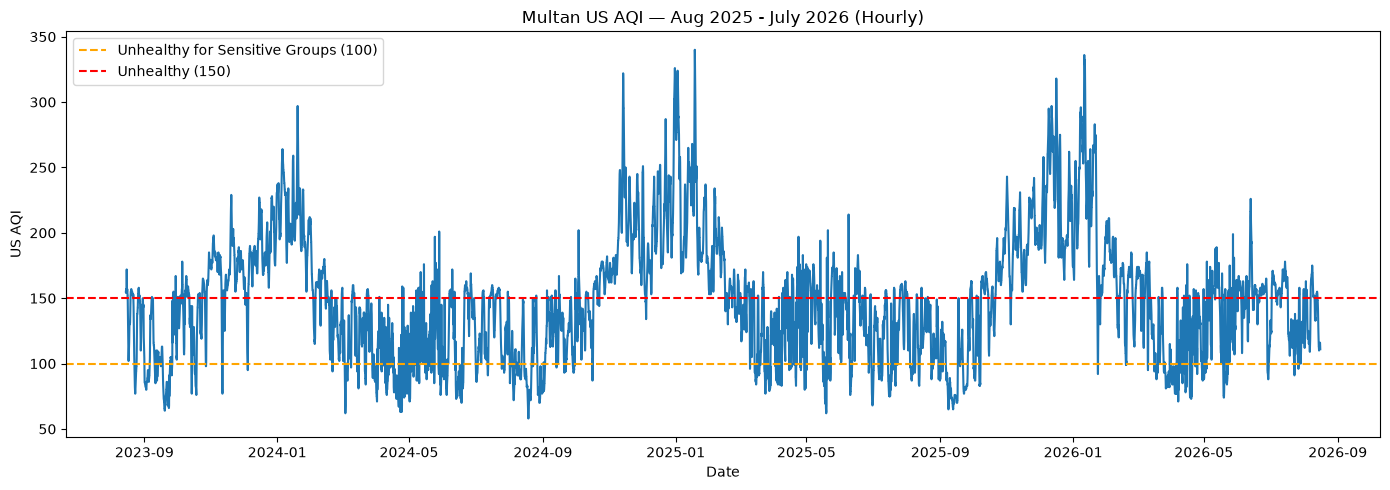

In [67]:
plt.figure(figsize=(14, 5))
plt.plot(df_merged["time"], df_merged["us_aqi"])
plt.title("Multan US AQI — Aug 2025 - July 2026 (Hourly)")
plt.xlabel("Date")
plt.ylabel("US AQI")
plt.axhline(y=100, color='orange', linestyle='--', label='Unhealthy for Sensitive Groups (100)')
plt.axhline(y=150, color='red', linestyle='--', label='Unhealthy (150)')
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

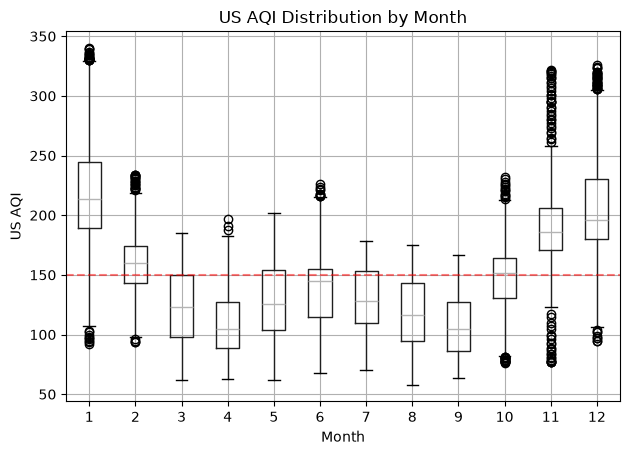

In [68]:
df_merged["month"] = df_merged["time"].dt.month

plt.figure(figsize=(12, 5))
df_merged.boxplot(column="us_aqi", by="month")
plt.title("US AQI Distribution by Month")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel("US AQI")
plt.axhline(y=150, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

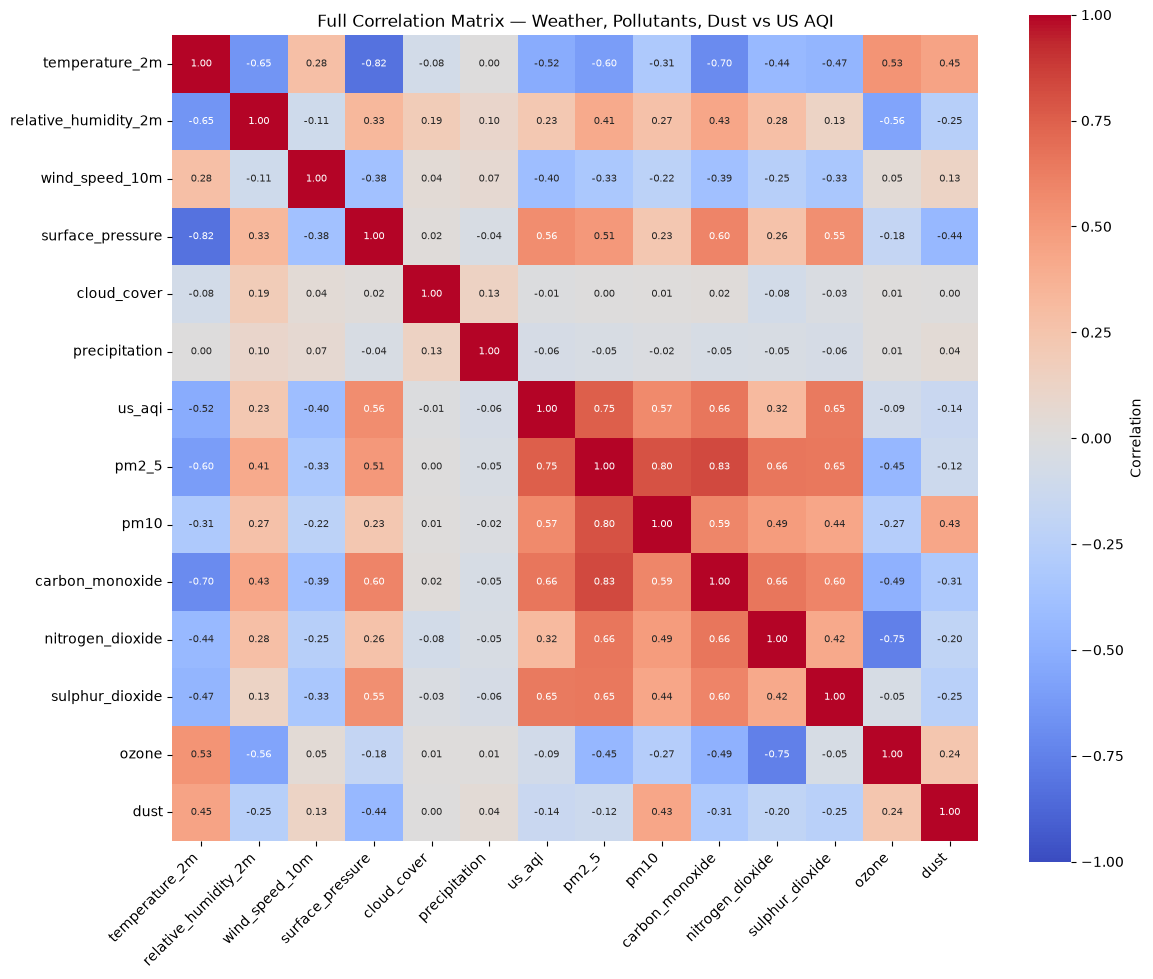

In [69]:
corr_cols = ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 
             'surface_pressure', 'cloud_cover', 'precipitation', 'us_aqi', 
             'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 
             'sulphur_dioxide', 'ozone', 'dust']

corr_matrix = df_merged[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "Correlation"}, annot_kws={"size": 7})
plt.title("Full Correlation Matrix — Weather, Pollutants, Dust vs US AQI")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

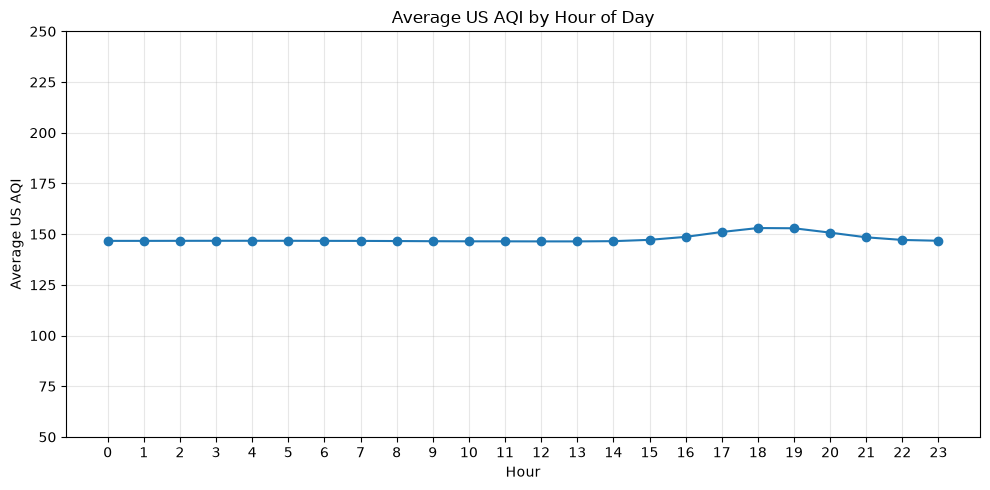

In [70]:
df_merged["hour"] = df_merged["time"].dt.hour

hourly_avg = df_merged.groupby("hour")["us_aqi"].mean()

plt.figure(figsize=(10, 5))
hourly_avg.plot(kind="line", marker="o")
plt.title("Average US AQI by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average US AQI")
plt.ylim(50, 250)
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Investigation the outliers in June

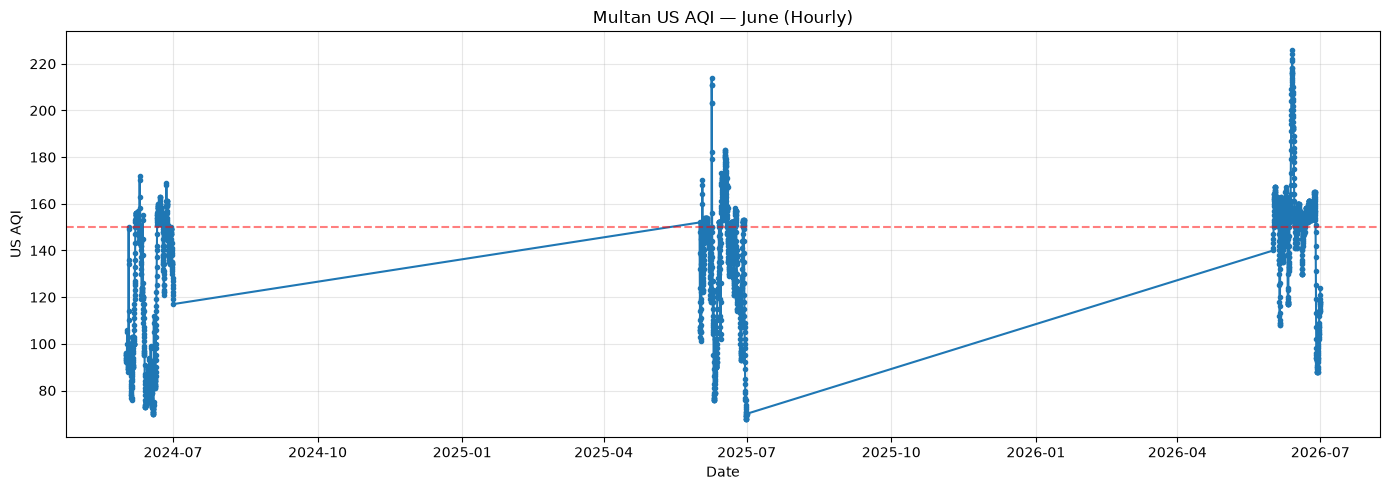

In [71]:
df_june = df_merged[df_merged["time"].dt.month == 6].copy()
df_june = df_june.sort_values("time")

plt.figure(figsize=(14, 5))
plt.plot(df_june["time"], df_june["us_aqi"], marker=".")
plt.title("Multan US AQI — June (Hourly)")
plt.xlabel("Date")
plt.ylabel("US AQI")
plt.axhline(y=150, color='red', linestyle='--', alpha=0.5)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [72]:
q1 = df_june["us_aqi"].quantile(0.25)
q3 = df_june["us_aqi"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df_june[(df_june["us_aqi"] < lower_bound) | (df_june["us_aqi"] > upper_bound)]
print(f"IQR bounds: {lower_bound:.1f} to {upper_bound:.1f}")
print(f"Number of outlier hours: {len(outliers)}")
outliers[["time", "us_aqi", "temperature_2m", "wind_speed_10m", "precipitation", "dust"]].sort_values("us_aqi")

IQR bounds: 55.0 to 215.0
Number of outlier hours: 10


,time,us_aqi,temperature_2m,wind_speed_10m,precipitation,dust
24787,2026-06-12 19:00:00,216,36.2,14.2,0.0,0.0
24788,2026-06-12 20:00:00,216,35.6,10.8,0.0,22.0
24789,2026-06-12 21:00:00,216,34.4,7.2,0.0,145.0
24790,2026-06-12 22:00:00,217,32.9,10.0,0.0,312.0
24791,2026-06-12 23:00:00,218,30.0,16.8,0.0,437.0
24796,2026-06-13 04:00:00,218,28.0,11.4,0.0,425.0
24792,2026-06-13 00:00:00,221,29.5,9.9,0.0,480.0
24795,2026-06-13 03:00:00,222,28.5,9.9,0.0,454.0
24794,2026-06-13 02:00:00,224,29.2,9.1,0.0,475.0
24793,2026-06-13 01:00:00,226,29.4,7.5,0.0,482.0


In [73]:
df_merged.to_csv(r"..\Data\sample_data.csv",index=False)